In [88]:
import os

# Local project layout (this notebook lives in the "code" subfolder, with
# "data" as a sibling directory). No Colab / Google Drive mount needed --
# just make sure we're running from this notebook's own directory so that
# relative paths like "../data/..." resolve correctly regardless of where
# Jupyter itself was launched from.
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
os.chdir(notebook_dir)

import torch
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, TransformerConv
from torch.optim import Adam
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # Progress bar
import matplotlib.pyplot as plt
import pickle as pkl

# Plot heatmap of Sharpe ratios

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


In [89]:
# This notebook (originally written against the paper authors' FactSet Revere-based
# pipeline) hardcodes the column name 'FACTSET_ENTITY_ID' as the firm identifier in dozens
# of places throughout the rest of this notebook (R2 section, spanning regressions,
# transaction-cost experiments, etc.). Our pipeline uses 'gvkey' as the firm identifier
# instead (via the WRDS Compustat Segment supply chain substitute). Rather than patch
# every hardcoded reference individually, we just alias gvkey to FACTSET_ENTITY_ID here,
# once, so every downstream cell that expects that column name finds it -- no other logic
# anywhere else in this notebook needs to change.
df['FACTSET_ENTITY_ID'] = df['gvkey'].astype(str)

#NN Benchmark: Multi-Layer Perceptron

In [90]:
### MLP ###
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam


# -----------------------------
# Dataset
# -----------------------------
class PanelDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, node_idx: np.ndarray, yyyymm: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.node_idx = torch.tensor(node_idx, dtype=torch.long)
        self.yyyymm = yyyymm

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i], self.node_idx[i], self.yyyymm[i]


# -----------------------------
# MLP Model (configurable hidden layers)
# -----------------------------
class MLPModel(nn.Module):
    """
    Returns (predictions, embeddings) where embeddings has dimension embedding_dim,
    similar to your GNN returning (out(x), x_embedding).
    """
    def __init__(
        self,
        input_dim: int,
        embedding_dim: int = 16,
        num_hidden_layers: int = 2,
        hidden_dim: int = 64,
        dropout: float = 0.3,
        use_batchnorm: bool = True,
    ):
        super().__init__()

        layers = []
        in_dim = input_dim

        # BN on raw features
        self.bn_in = nn.BatchNorm1d(input_dim) if use_batchnorm else None

        # hidden stack
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim

        # embedding head (so embeddings always have size embedding_dim)
        self.to_embedding = nn.Linear(in_dim, embedding_dim)

        # output head
        self.out = nn.Linear(embedding_dim, 1)

        self.hidden = nn.Sequential(*layers)

    def forward(self, x):
        if self.bn_in is not None:
            x = self.bn_in(x)

        x = self.hidden(x)              # (B, hidden_dim) or (B, input_dim) if no hidden layers
        emb = F.relu(self.to_embedding(x))  # (B, embedding_dim)
        pred = self.out(emb)            # (B, 1)
        return pred, emb


# -----------------------------
# Training function
# -----------------------------
def train_mlp_panel(
    df: pd.DataFrame,
    feature_cols: list,
    split_yyyymm,
    target_col: str = "mthret",
    entity_col: str = "FACTSET_ENTITY_ID",
    month_col: str = "yyyymm",
    embedding_dim: int = 16,
    num_hidden_layers: int = 2,
    hidden_dim: int = 64,
    epochs: int = 80,
    batch_size: int = 1024,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.3,
    use_batchnorm: bool = True,
    device: str = None,
    global_node_map: dict = None,
    save_csv_prefix: str = None,
):
    """
    MLP version of your GNN train_model:
    - Splits by yyyymm threshold
    - Trains on (X=feature_cols, y=target_col)
    - Returns prediction + embedding panels matching your GNN output format.

    Outputs:
      model, train_losses, test_losses,
      train_corrections_df, train_embeddings_df,
      test_corrections_df, test_embeddings_df
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- clean & keep only needed cols
    needed_cols = [month_col, entity_col, target_col] + list(feature_cols)
    work = df[needed_cols].copy()

    # ensure month comparable

    work[month_col] = work[month_col].astype(str)

    # drop missing in X/y
    work = work.dropna(subset=[target_col] + list(feature_cols) + [month_col, entity_col]).copy()

    # --- node mapping
    if global_node_map is None:
        unique_entities = pd.Index(work[entity_col].unique())
        global_node_map = {ent: i for i, ent in enumerate(unique_entities)}
    node_gvkey_df = pd.DataFrame(
        [(ent, idx) for ent, idx in global_node_map.items()],
        columns=[entity_col, "node_idx"]
    )

    work["node_idx"] = work[entity_col].map(global_node_map).astype(int)

    # --- split
    split_yyyymm = str(split_yyyymm)
    train_mask = work[month_col].astype(str) <= split_yyyymm
    test_mask  = work[month_col].astype(str) > split_yyyymm

    train_df = work.loc[train_mask].copy()
    test_df  = work.loc[test_mask].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("Invalid split_yyyymm: need observations on both sides of the split.")

    # --- build X/y
    X_train = train_df[feature_cols].to_numpy(dtype=np.float32)
    y_train = train_df[target_col].to_numpy(dtype=np.float32)

    X_test  = test_df[feature_cols].to_numpy(dtype=np.float32)
    y_test  = test_df[target_col].to_numpy(dtype=np.float32)

    # --- standardize using train stats only
    #mu = X_train.mean(axis=0)
    #sd = X_train.std(axis=0)
    #sd[sd == 0] = 1.0

    #X_train = (X_train - mu) / sd
    #X_test  = (X_test  - mu) / sd

    # --- datasets/loaders
    train_ds = PanelDataset(
        X_train, y_train,
        node_idx=train_df["node_idx"].to_numpy(),
        yyyymm=train_df[month_col].to_numpy()
    )
    test_ds = PanelDataset(
        X_test, y_test,
        node_idx=test_df["node_idx"].to_numpy(),
        yyyymm=test_df[month_col].to_numpy()
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # --- model/opt
    model = MLPModel(
        input_dim=len(feature_cols),
        embedding_dim=embedding_dim,
        num_hidden_layers=num_hidden_layers,
        hidden_dim=hidden_dim,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
    ).to(device)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []

    # --- train loop
    for epoch in tqdm(range(epochs), desc="MLP Training Progress"):
        model.train()
        total_train_loss = 0.0

        for Xb, yb, _, _ in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device).unsqueeze(1)  # (B,1)

            optimizer.zero_grad()
            pred, _ = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        model.eval()
        total_test_loss = 0.0
        with torch.no_grad():
            for Xb, yb, _, _ in test_loader:
                Xb = Xb.to(device)
                yb = yb.to(device).unsqueeze(1)
                pred, _ = model(Xb)
                total_test_loss += criterion(pred, yb).item()

        train_losses.append(total_train_loss / max(1, len(train_loader)))
        test_losses.append(total_test_loss / max(1, len(test_loader)))

    # --- inference to build output panels
    def build_output_panels(df_part: pd.DataFrame, X_part: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
        model.eval()

        # batch inference over rows
        ds = PanelDataset(
            X_part,
            df_part[target_col].to_numpy(dtype=np.float32),
            node_idx=df_part["node_idx"].to_numpy(),
            yyyymm=df_part[month_col].to_numpy()
        )
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)

        preds_list = []
        embs_list = []
        node_idx_list = []
        yyyymm_list = []

        with torch.no_grad():
            for Xb, _, node_idx_b, yyyymm_b in loader:
                Xb = Xb.to(device)
                pred_b, emb_b = model(Xb)

                preds_list.append(pred_b.squeeze(1).cpu().numpy())
                embs_list.append(emb_b.cpu().numpy())
                node_idx_list.append(node_idx_b.cpu().numpy())
                yyyymm_list.append(np.array(yyyymm_b, dtype=object))

        preds = np.concatenate(preds_list, axis=0)
        embs = np.concatenate(embs_list, axis=0)
        node_idx_arr = np.concatenate(node_idx_list, axis=0)
        yyyymm_arr = np.concatenate(yyyymm_list, axis=0)

        base = pd.DataFrame({
            "node_idx": node_idx_arr,
            "yyyymm": yyyymm_arr.astype(str),
        })

        # predictions panel
        pred_df = base.copy()
        pred_df["predicted_correction"] = preds

        # embeddings panel
        emb_df = base.copy()
        for i in range(embedding_dim):
            emb_df[f"embedding_dim_{i}"] = embs[:, i]

        # merge in FACTSET_ENTITY_ID
        pred_df = pred_df.merge(node_gvkey_df, on="node_idx", how="left")
        emb_df  = emb_df.merge(node_gvkey_df, on="node_idx", how="left")

        return pred_df, emb_df

    train_corrections_df, train_embeddings_df = build_output_panels(train_df, X_train)
    test_corrections_df, test_embeddings_df = build_output_panels(test_df, X_test)

    # drop node_idx column from all dataframes
    train_corrections_df.drop("node_idx", axis=1, inplace=True)
    train_embeddings_df.drop("node_idx", axis=1, inplace=True)
    test_corrections_df.drop("node_idx", axis=1, inplace=True)
    test_embeddings_df.drop("node_idx", axis=1, inplace=True)

    train_corrections_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_train_corrections_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)
    train_embeddings_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_train_embeddings_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)
    test_corrections_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_test_corrections_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)
    test_embeddings_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_test_embeddings_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)

    return (
        model,
        train_losses,
        test_losses,
        train_corrections_df,
        train_embeddings_df,
        test_corrections_df,
        test_embeddings_df,
    )

In [91]:
# drop duplicates from df
df = df.drop_duplicates()

In [93]:
model, train_losses, test_losses, train_pred, train_emb, test_pred, test_emb = train_mlp_panel(
    df=df,
    feature_cols=feature_cols,
    entity_col="gvkey",  # our pipeline uses gvkey as the firm identifier, not FACTSET_ENTITY_ID
    split_yyyymm="201612",
    embedding_dim=40,
    num_hidden_layers=2,
    hidden_dim=40, #128,
    epochs=80,
    batch_size=32, dropout=0, lr=.001, weight_decay=1e-4)

MLP Training Progress: 100%|█████████████████████████████████████████████| 80/80 [10:33<00:00,  7.92s/it]


In [ ]:
model, train_losses, test_losses, train_pred, train_emb, test_pred, test_emb = train_mlp_panel(
    df=df,
    feature_cols=feature_cols,
    entity_col="gvkey",  # our pipeline uses gvkey as the firm identifier, not FACTSET_ENTITY_ID
    split_yyyymm="201612",
    embedding_dim=40,
    num_hidden_layers=3,
    hidden_dim=40, #128,
    epochs=80,
    batch_size=32, dropout=0, lr=.001, weight_decay=1e-4)

MLP Training Progress:   8%|███▍                                          | 6/80 [00:51<10:34,  8.58s/it]

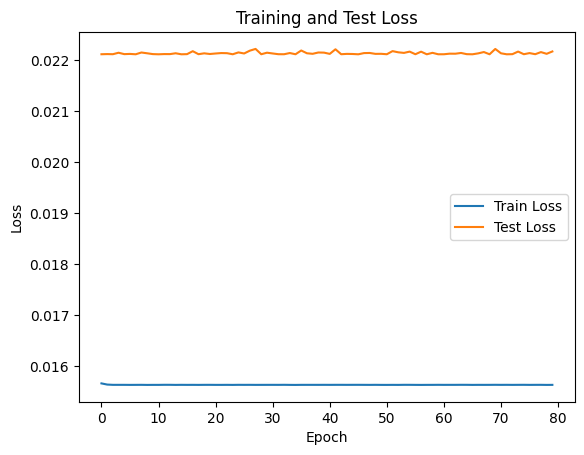

In [96]:
# plot traain and test losses
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.show()

# Cross-Sectional R2 for GNN

In [98]:
### Monthly R2 ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Row-wise (monthly) R^2 ---
def r2_by_month(residuals_df: pd.DataFrame, true_returns_df: pd.DataFrame) -> pd.Series:
    """
    Compute cross-sectional R^2 for each month t:
        R2_t = 1 - sum_i eps_{t,i}^2 / sum_i (y_{t,i} - mean_i y_{t,i})^2
    Handles missing values per month.
    """
    # Align on same index/columns
    resid, y = residuals_df.align(true_returns_df, join="inner", axis=1)
    resid, y = resid.align(y, join="inner", axis=0)

    r2_vals = []
    idx = resid.index

    for t in idx:
        e = resid.loc[t].to_numpy(dtype=float)
        yt = y.loc[t].to_numpy(dtype=float)

        mask = np.isfinite(e) & np.isfinite(yt)
        if mask.sum() < 2:
            r2_vals.append(np.nan)
            continue

        e = e[mask]
        yt = yt[mask]

        ss_res = np.sum(e**2)
        yt_mean = np.mean(yt)
        ss_tot = np.sum((yt - yt_mean) ** 2)

        if ss_tot <= 0 or not np.isfinite(ss_tot):
            r2_vals.append(np.nan)
        else:
            r2_vals.append(1.0 - ss_res / ss_tot)

    return pd.Series(r2_vals, index=idx, name="R2")


# --- 2)
# NOTE: our pipeline's train/test correction CSVs (saved by GNN model.ipynb) key firms
# by 'gvkey', not 'FACTSET_ENTITY_ID' -- this mirrors the already-working
# prepare_residuals_and_true_returns_direct() defined in GNN model.ipynb, using 'gvkey'
# throughout instead of the original FactSet-based column name.
def prepare_residuals_and_true_returns_direct(df, predictions_rppca, train_corrections, test_corrections):
    true_long = pd.melt(df.reset_index(), id_vars=['yyyymm']).dropna()
    true_long.columns = ['yyyymm', 'gvkey', 'trueY']
    true_long['gvkey'] = true_long['gvkey'].astype(float).astype(int)

    predictions_bench_long = pd.melt(predictions_rppca, id_vars=['yyyymm'])
    predictions_bench_long.columns = ['yyyymm', 'gvkey', 'benchPrediction']
    predictions_bench_long['gvkey'] = predictions_bench_long['gvkey'].astype(float).astype(int)

    predictions_bench_long = pd.merge(true_long, predictions_bench_long, on=['yyyymm', 'gvkey'])
    predictions_bench_long['bench_eps'] = predictions_bench_long['trueY'] - predictions_bench_long['benchPrediction']

    predictions_bench_train = pd.merge(train_corrections.dropna(), predictions_bench_long,
                                       on=['yyyymm', 'gvkey'], how='left')
    predictions_bench_test  = pd.merge(test_corrections.dropna(), predictions_bench_long,
                                       on=['yyyymm', 'gvkey'], how='left')

    for df_split in [predictions_bench_train, predictions_bench_test]:
        # "direct": predicted_correction is the prediction itself
        df_split['hatY'] = df_split['predicted_correction']
        df_split['gnn_eps'] = df_split['trueY'] - df_split['hatY']

    residuals_bench_train = predictions_bench_train.pivot(index='yyyymm', columns='gvkey', values='bench_eps')
    residuals_bench_test  = predictions_bench_test.pivot(index='yyyymm', columns='gvkey', values='bench_eps')
    residuals_gnn_train   = predictions_bench_train.pivot(index='yyyymm', columns='gvkey', values='gnn_eps')
    residuals_gnn_test    = predictions_bench_test.pivot(index='yyyymm', columns='gvkey', values='gnn_eps')

    true_returns_train = predictions_bench_train.pivot(index='yyyymm', columns='gvkey', values='trueY')
    true_returns_test  = predictions_bench_test.pivot(index='yyyymm', columns='gvkey', values='trueY')

    return (residuals_bench_train, residuals_bench_test,
            residuals_gnn_train, residuals_gnn_test,
            true_returns_train, true_returns_test)


# --- 3) Compute MONTHLY R^2 time series for each model  ---
def monthly_r2_timeseries_for_models_direct(
    models: dict,
    df_true_returns: pd.DataFrame,
    predictions_rppca: pd.DataFrame,
    benchmark_name: str = "RP-PCA",
    split: str = "test",                 # "train" or "test"
    include_benchmark: bool = True
) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by yyyymm with one column per model (and optionally benchmark),
    containing monthly cross-sectional R^2.
    """
    if split not in {"train", "test"}:
        raise ValueError("split must be 'train' or 'test'")

    out = {}

    for model_key, (train_corrections, test_corrections) in models.items():
        (resid_bench_train, resid_bench_test,
         resid_model_train, resid_model_test,
         y_train, y_test) = prepare_residuals_and_true_returns_direct(
            df_true_returns, predictions_rppca, train_corrections, test_corrections
        )

        if split == "train":
            resid_bench, resid_model, y = resid_bench_train, resid_model_train, y_train
        else:
            resid_bench, resid_model, y = resid_bench_test, resid_model_test, y_test

        # Benchmark
        if include_benchmark:
            out[benchmark_name] = r2_by_month(resid_bench, y)

        # Model
        out[model_key] = r2_by_month(resid_model, y)

    r2_df = pd.concat(out, axis=1)


    r2_df = r2_df.sort_index()

    return r2_df


# --- 4) Plot:
def plot_r2_timeseries(r2_df: pd.DataFrame, title: str = "Monthly cross-sectional $R^2$"):
    plt.figure(figsize=(12, 6))
    for col in r2_df.columns:
        plt.plot(r2_df.index, r2_df[col], label=col)
    plt.title(title)
    plt.xlabel("yyyymm")
    plt.ylabel("R^2")
    plt.legend(fontsize=8, ncol=1, loc="best")
    plt.tight_layout()
    plt.show()



models = load_models_from_files(model_names, layer_values, num_heads, dim_values, dropout_rates, epoch_grid)

r2_df_test = monthly_r2_timeseries_for_models_direct(
    models=models,
    df_true_returns=true_returns,
    predictions_rppca=predictions_rppca,
    benchmark_name="RP-PCA",
    split="test",
    include_benchmark=True
)

# drop RP-PCA column
r2_df_test = r2_df_test.drop(columns=['RP-PCA'])

# Plot
#plot_r2_timeseries(r2_df_test, title="Test monthly cross-sectional $R^2$")

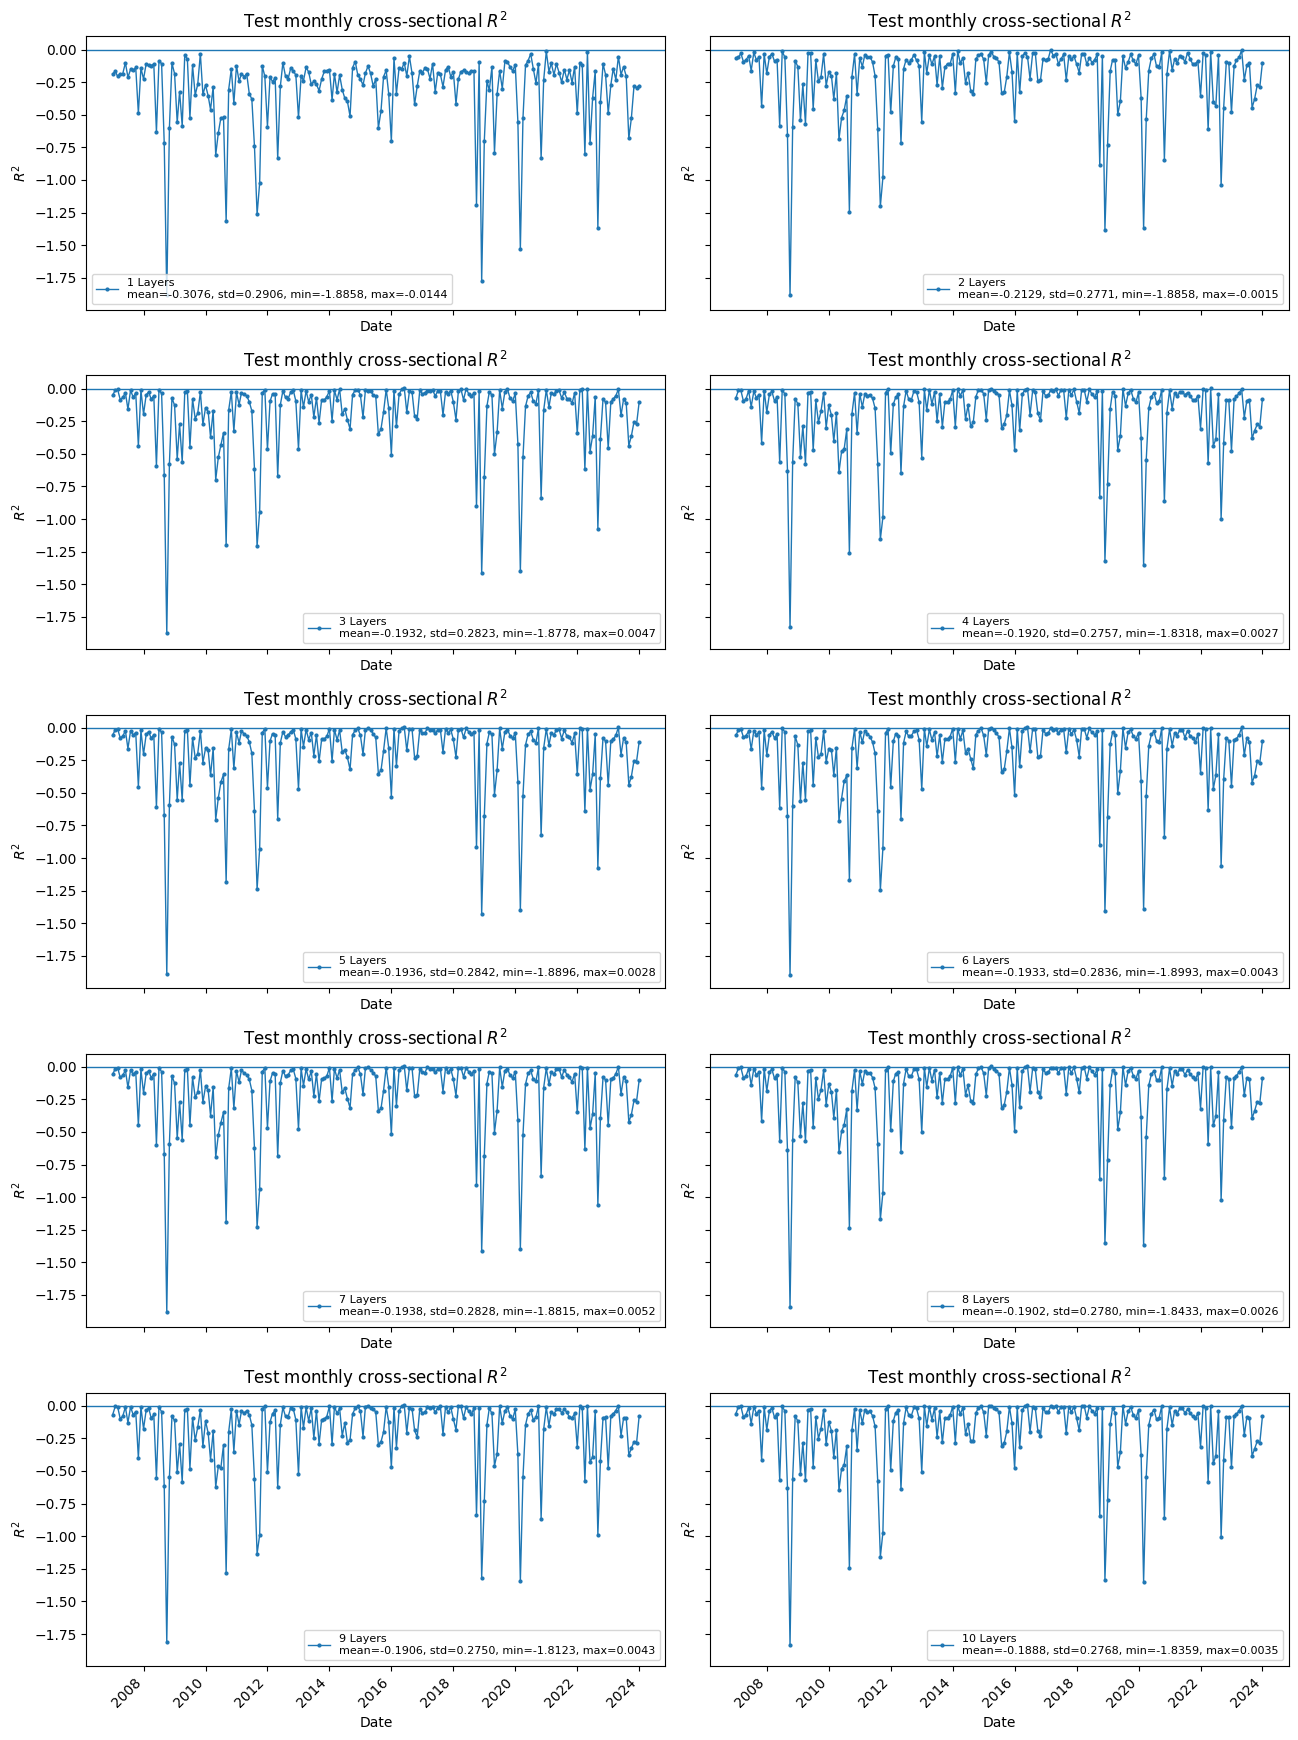

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

df = r2_df_test.copy()

# ---- 1) Ensure index is datetime (monthly) ----

idx = df.index.astype(str)
df.index = pd.to_datetime(idx, format="%Y%m")  # month start timestamps

# ---- 2) Sort index ----
df = df.sort_index()

# ---- 3) If duplicates exist, aggregate (optional but common) ----


cols = df.columns.tolist()
n = len(cols)

# ---- 4) Grid layout ----
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6.5*ncols, 3.5*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cols):
    ax = axes[i]
    y = df[col]

    mu = y.mean(skipna=True)
    sd = y.std(skipna=True)
    min=y.min(skipna=True)
    max=y.max(skipna=True)

    label = f"{i+1} Layers\nmean={mu:.4f}, std={sd:.4f}, min={min:.4f}, max={max:.4f}"

    ax.plot(df.index, y, marker="o", markersize=2, linewidth=1, label=label)
    ax.axhline(0, linewidth=1)
    ax.set_title("Test monthly cross-sectional $R^2$")
    ax.set_ylabel("$R^2$")
    ax.legend(fontsize=8, loc="best")

# turn off unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# x-axis formatting
fig.autofmt_xdate(rotation=45)
for ax in axes[:n]:
    ax.set_xlabel("Date")

fig.tight_layout()
plt.show()

In [100]:
r2_df_test

,Transformer_ALL_firms_layers_1_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_2_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_3_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_4_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_5_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_6_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_7_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_8_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_9_heads_2_embed_dim_40_dropout_0.5_epochs_6,Transformer_ALL_firms_layers_10_heads_2_embed_dim_40_dropout_0.5_epochs_6
yyyymm,,,,,,,,,,
200701,-0.186574,-0.062204,-0.050757,-0.072774,-0.057490,-0.058473,-0.059403,-0.063527,-0.071141,-0.060936
200702,-0.166453,-0.060399,-0.014025,-0.011277,-0.017928,-0.018839,-0.016327,-0.010142,-0.004973,-0.005699
200703,-0.204877,-0.028589,-0.005842,-0.013220,-0.009912,-0.009112,-0.006116,-0.005868,-0.006438,-0.003614
200704,-0.186642,-0.094089,-0.083894,-0.097464,-0.077697,-0.073981,-0.082306,-0.087301,-0.098716,-0.088509
200705,-0.185212,-0.079784,-0.068176,-0.079294,-0.065014,-0.060163,-0.066938,-0.071635,-0.079698,-0.067901
...,...,...,...,...,...,...,...,...,...,...
202309,-0.681363,-0.446137,-0.436815,-0.382603,-0.437138,-0.421653,-0.422747,-0.395476,-0.377723,-0.385306
202310,-0.526749,-0.378745,-0.363405,-0.321697,-0.375345,-0.367011,-0.367906,-0.338841,-0.325926,-0.328299
202311,-0.280437,-0.272186,-0.255309,-0.275276,-0.251951,-0.257709,-0.258710,-0.267246,-0.276538,-0.271565


## Skipped: FactSet-benchmark-dependent sections

Everything from here to the end of the notebook (oversmoothing experiments, asset pricing factor / spanning regressions, HJD, and the multi-step transaction cost experiments) reads precomputed reference files from `data/factset_tests/` and `data/3_lag_tests_factset/`. Those are the original paper authors' own FactSet Revere-based benchmark outputs (specific epoch/layer/l2_reg configs we never ran), not something our WRDS-substitute pipeline produces. They exist purely to compare our GNN against the authors' own benchmark portfolios/factors for performance measurement -- not a dependency of the GNN or MLP training itself.

Per project decision, these comparison cells are skipped (converted to raw/non-executing cells, source preserved below for reference) rather than faked with mismatched configs.

# GNN Oversmoothing Experiments

# Decile Portfolio Time Series: SCG Factor

# Asset Pricing Tests

## Time Series Regressions Against Test Assets

## Hansen-Jagannathan Distance

## Spanning Regressions

# Multi-Step Transaction Cost Experiments